In [2]:
# importing libraries
%matplotlib inline
!pip install plotly-express

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

from scipy import stats
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')


In [3]:

# reading raw data file
columns = ['timestamp', 'accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']
dfs = list()

for file in os.listdir('./tcp_server/out_converted/15_05_test'):
    har_df = pd.read_csv('./tcp_server/out_converted/15_05_test/'+ file, header = 0, names = columns, on_bad_lines='skip')
    har_df['activity'] = file.split('.')[0]
    har_df['index'] = int(file.split('.')[1])
    dfs.append(har_df)

df = pd.concat(dfs, ignore_index=True)

# # removing null values
# har_df = har_df.dropna()
# har_df.shape

# # transforming the z-axis to float
# har_df['z-axis'] = har_df['z-axis'].str.replace(';', '')
# har_df['z-axis'] = har_df['z-axis'].apply(lambda x:float(x))

# # drop the rows where timestamp is 0
# df = har_df[har_df['timestamp'] != 0]

# now arrange data in ascending order of the user and timestamp
# df = df.sort_values(by = ['user', 'timestamp'], ignore_index=True)

In [4]:
print(df)

       timestamp  accX  accY   accZ  gyroX  gyroY  gyroZ  activity  index
0              8 -0.88  0.50  10.23   0.09  -0.02  -0.13     Break      1
1             26 -1.68  0.08   7.28  -0.21   0.04  -0.18     Break      1
2             46  0.04  0.08   7.97  -0.17  -0.08  -0.17     Break      1
3             67  2.57  0.15  12.41  -0.11   0.07  -0.12     Break      1
4             87 -0.84  0.23   8.20  -0.11   0.04  -0.11     Break      1
...          ...   ...   ...    ...    ...    ...    ...       ...    ...
48783       4921 -0.92 -1.34   8.35  -0.01   0.04   0.28  Straight     40
48784       4841 -1.84 -1.11  10.46  -0.08  -0.04   0.06  Straight     40
48785       4861  0.57 -1.84   7.62  -0.08  -0.04   0.06  Straight     40
48786       4882 -1.34 -1.38  11.19  -0.02   0.01   0.17  Straight     40
48787       4901  2.22 -1.49  11.84  -0.04   0.00   0.24  Straight     40

[48788 rows x 9 columns]


In [5]:
max = df[df['activity'] == 'Break'].max(axis='index')['index']
print(max)	

48


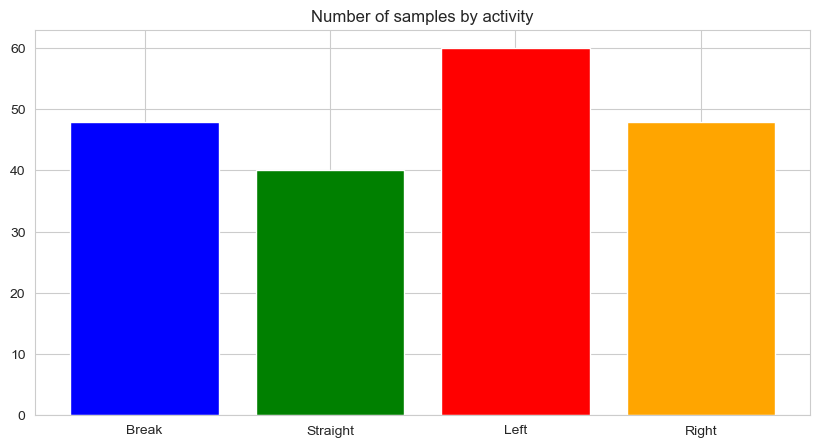

In [6]:
sns.set_style("whitegrid")
plt.figure(figsize = (10, 5))
max_break = df[df['activity'] == 'Break'].max(axis='index')['index']
max_straight = df[df['activity'] == 'Straight'].max(axis='index')['index']
max_left = df[df['activity'] == 'Left'].max(axis='index')['index']
max_right = df[df['activity'] == 'Right'].max(axis='index')['index']
plt.bar(['Break', 'Straight', 'Left', 'Right'], [max_break, max_straight, max_left, max_right], color = ['blue', 'green', 'red', 'orange'])
plt.title('Number of samples by activity')
plt.show()

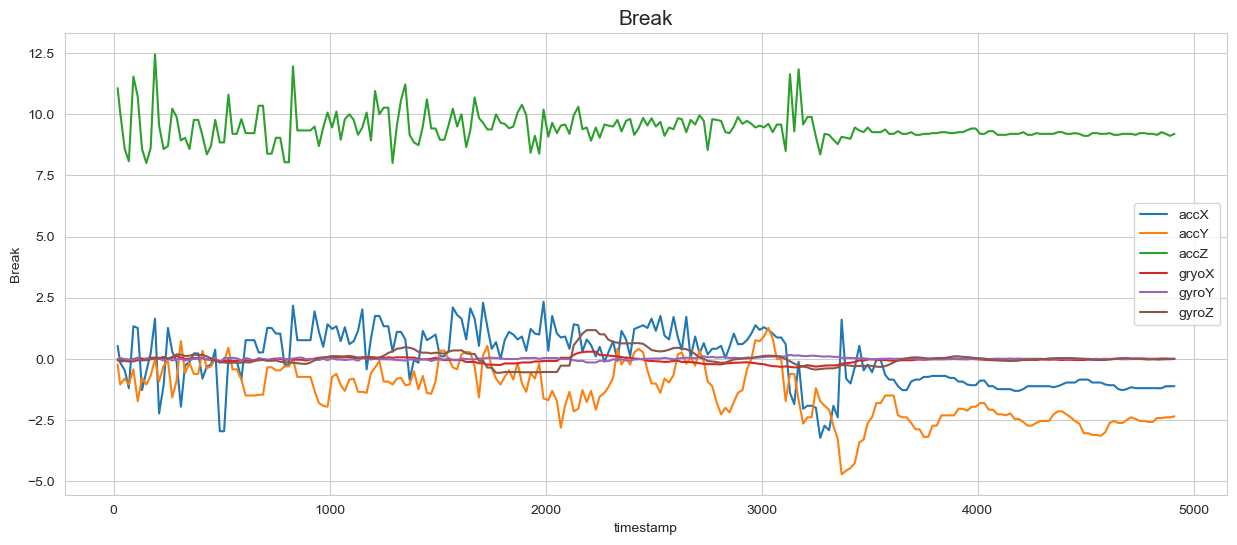

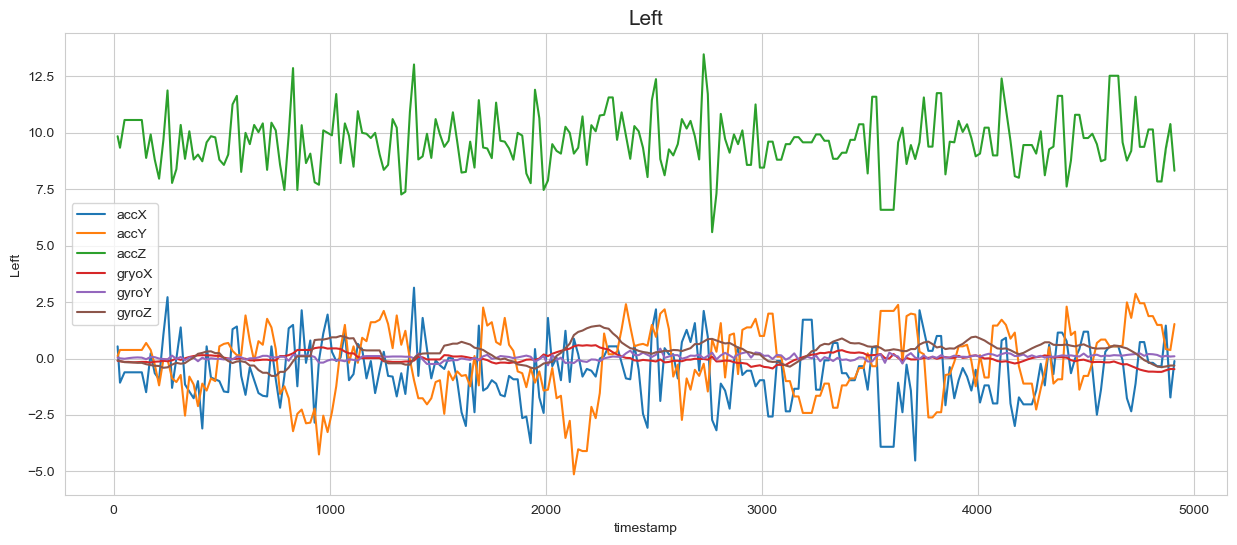

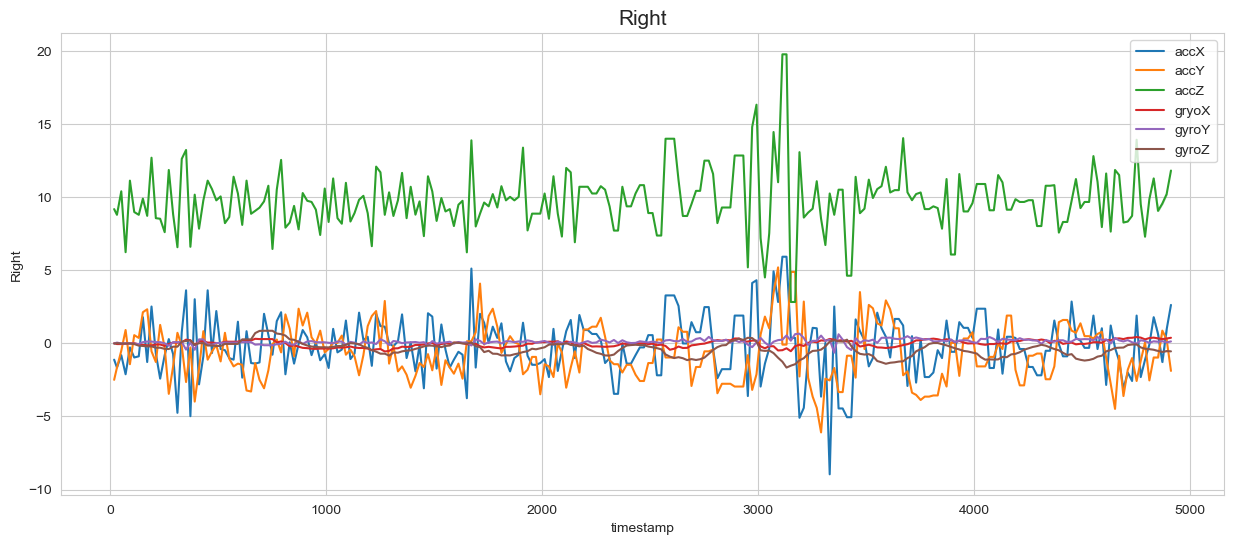

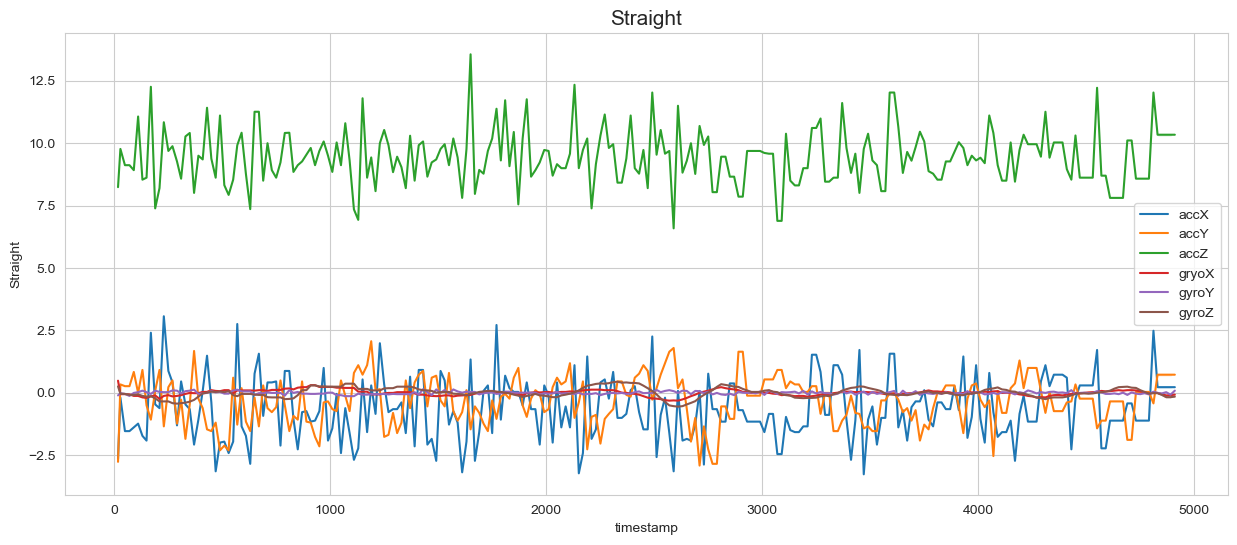

In [7]:
for i in ['Break', 'Left', 'Right', 'Straight']:
  data_36 = df[(df['index'] == 10) & (df['activity'] == i)][:400]
  plt.figure(figsize = (15, 6))
  sns.lineplot(y = 'accX', x = 'timestamp', data = data_36, label= 'accX')
  sns.lineplot(y = 'accY', x = 'timestamp', data = data_36, label= 'accY')
  sns.lineplot(y = 'accZ', x = 'timestamp', data = data_36, label= 'accZ')
  sns.lineplot(y = 'gyroX', x = 'timestamp', data = data_36, label= 'gryoX')
  sns.lineplot(y = 'gyroY', x = 'timestamp', data = data_36, label= 'gyroY')
  sns.lineplot(y = 'gyroZ', x = 'timestamp', data = data_36, label= 'gyroZ')
  plt.ylabel(i)
  plt.title(i, fontsize = 15)
  plt.show()

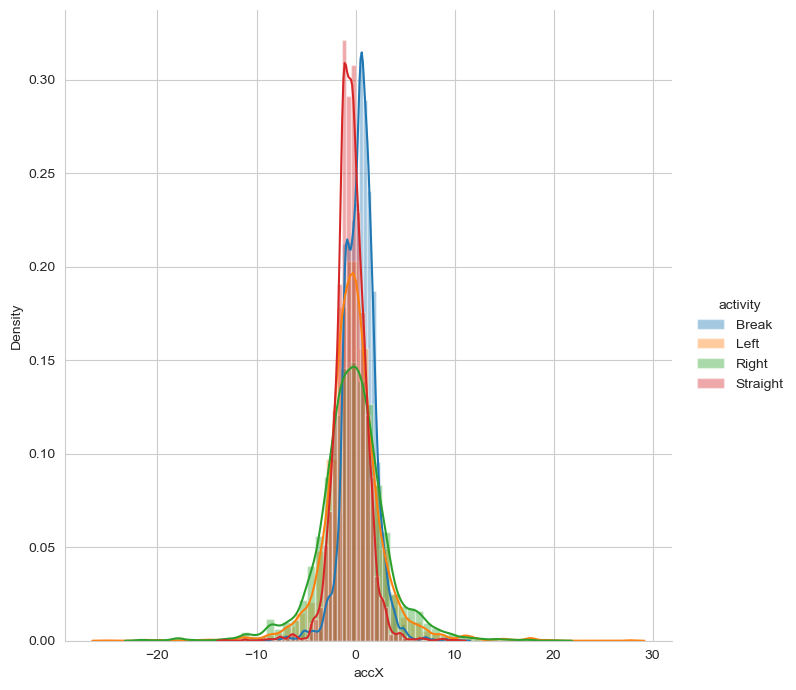

In [8]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accX').add_legend()
g.map(sns.scatterplot)

plt.show()

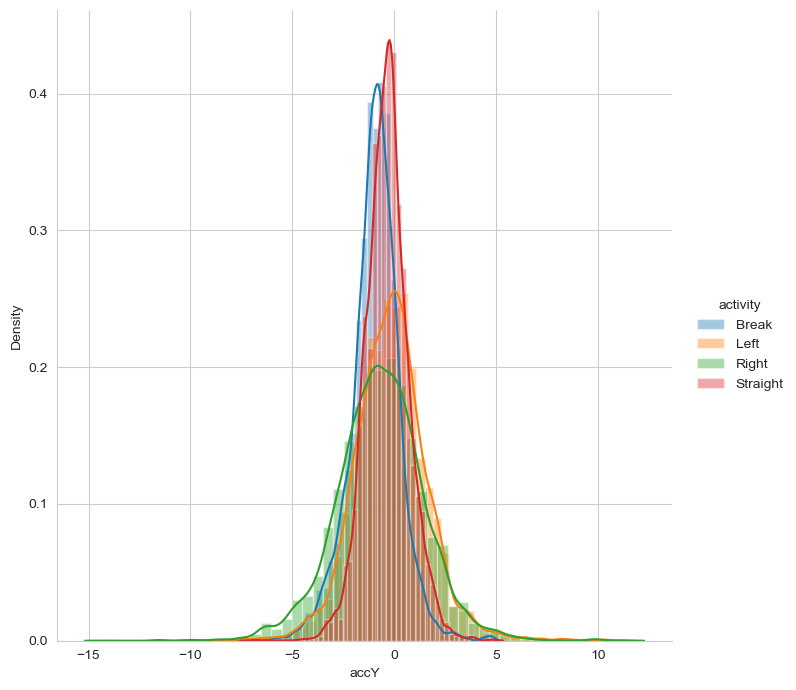

In [9]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accY').add_legend()
g.map(sns.scatterplot)
plt.show()

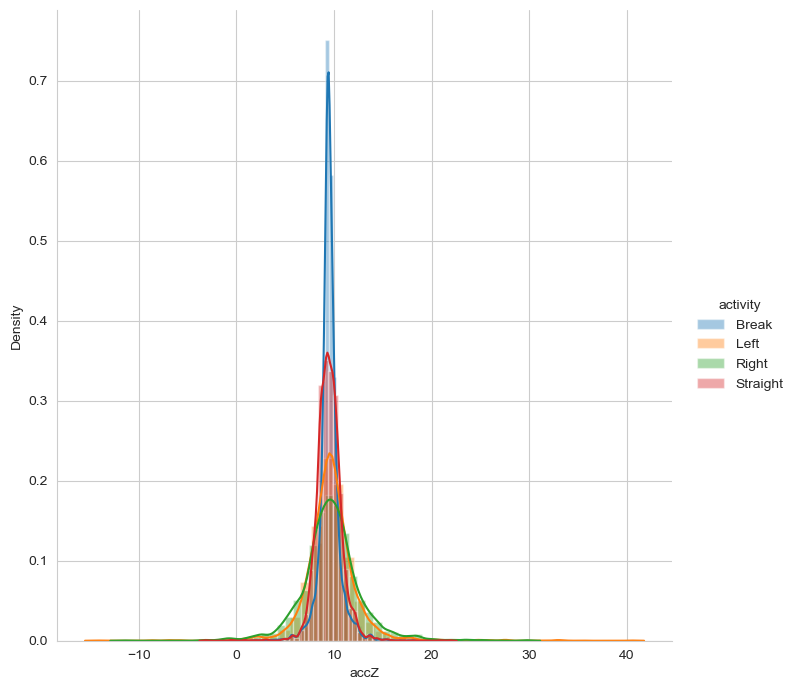

In [10]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'accZ').add_legend()
g.map(sns.scatterplot)
plt.show()

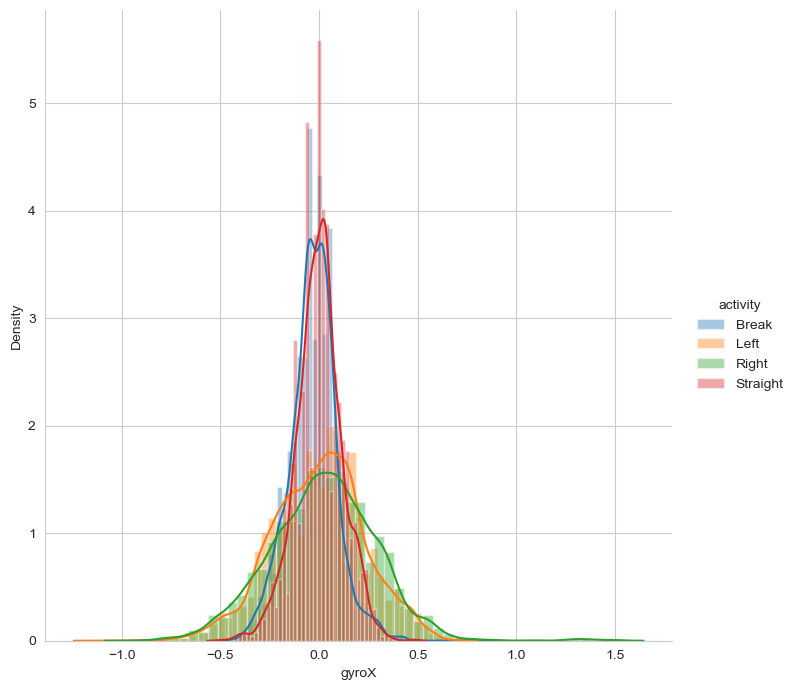

In [11]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroX').add_legend()
g.map(sns.scatterplot)
plt.show()

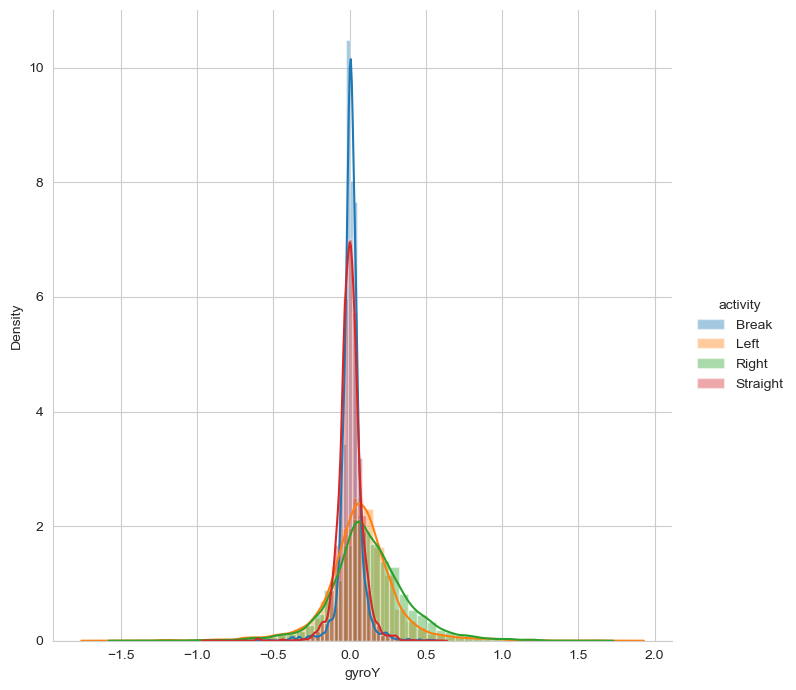

In [12]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroY').add_legend()
g.map(sns.scatterplot)
plt.show()

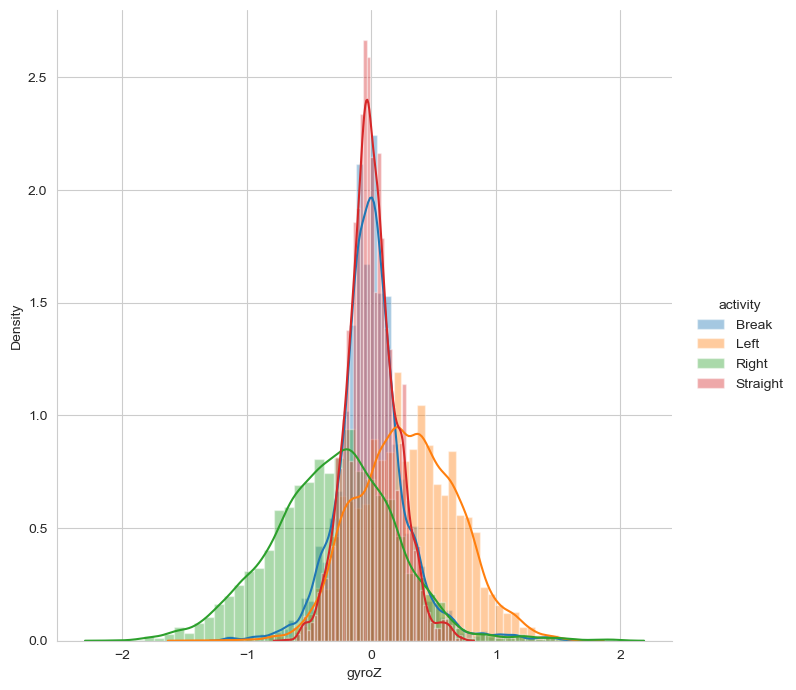

In [13]:
g = sns.FacetGrid(df, hue = 'activity', height=7).map(sns.distplot, 'gyroZ').add_legend()
g.map(sns.scatterplot)
plt.show()

In [14]:
# train data -> Users upto User ID = 27 (i.e. 27 users)


mask_train_break = (df['index'] <= (math.floor(max_break * 0.8))) & (df['activity'] == 'Break')
mask_train_straight = (df['index'] <= (math.floor(max_straight * 0.8))) & (df['activity'] == 'Straight')
mask_train_left = (df['index'] <= (math.floor(max_left * 0.8))) & (df['activity'] == 'Left')
mask_train_right = (df['index'] <= (math.floor(max_right * 0.8))) & (df['activity'] == 'Right')

df_train = pd.concat([df[mask_train_break], df[mask_train_straight], df[mask_train_left], df[mask_train_right]])

# test data -> Users from User ID = 28 to 36 (i.e. 9 users)
mask_test_break = (df['index'] > (math.floor(max_break * 0.8))) & (df['activity'] == 'Break')
mask_test_straight = (df['index'] > (math.floor(max_straight * 0.8))) & (df['activity'] == 'Straight')
mask_test_left = (df['index'] > (math.floor(max_left * 0.8))) & (df['activity'] == 'Left')
mask_test_right = (df['index'] > (math.floor(max_right * 0.8))) & (df['activity'] == 'Right')


df_test = pd.concat([df[mask_test_break], df[mask_test_straight], df[mask_test_left], df[mask_test_right]])

print(df_test)


       timestamp  accX  accY   accZ  gyroX  gyroY  gyroZ activity  index
9497          20  1.80 -0.69  10.95  -0.03   0.01  -0.02    Break     39
9498          36 -0.38 -0.42  10.19   0.01   0.01   0.01    Break     39
9499          57  1.00  0.50   9.61   0.02  -0.02   0.07    Break     39
9500          76 -0.80 -1.07   9.35   0.01   0.00   0.08    Break     39
9501          97  0.77 -1.11   8.85   0.02  -0.03   0.11    Break     39
...          ...   ...   ...    ...    ...    ...    ...      ...    ...
38785       4921  1.38  0.61   9.39   0.07  -0.06   0.38    Right     48
38786       4840 -3.68  3.18   5.86   0.19   0.21   0.40    Right     48
38787       4861 -3.68  3.18   5.86  -0.06  -0.15   0.17    Right     48
38788       4881  0.92  0.61   9.16   0.14  -0.22   0.42    Right     48
38789       4900 -0.65 -0.04   8.24   0.01  -0.11   0.29    Right     48

[9798 rows x 9 columns]


In [15]:
xa_list = []
xg_list = []
ya_list = []
yg_list = []
za_list = []
zg_list = []
train_labels = []

window_size = 100
step_size = 50

# creating overlaping windows of size window-size 120
for i in range(0, df_train.shape[0] - window_size, step_size):
    xs_acc = df_train['accX'].values[i: i + window_size]
    ys_acc = df_train['accY'].values[i: i + window_size]
    zs_acc = df_train['accZ'].values[i: i + window_size]
    xs_gyro = df_train['gyroX'].values[i: i + window_size]
    ys_gyro = df_train['gyroY'].values[i: i + window_size]
    zs_gyro = df_train['gyroZ'].values[i: i + window_size]
    
    label = df_train['activity'][i: i + window_size].mode()[0]

    xa_list.append(xs_acc)
    xg_list.append(xs_gyro)
    ya_list.append(ys_acc)
    yg_list.append(ys_gyro)
    za_list.append(zs_acc)
    zg_list.append(zs_gyro)
    train_labels.append(label)

# Statistical Features on raw x, y and z in time domain
X_train = pd.DataFrame()

# mean
X_train['xa_mean'] = pd.Series(xa_list).apply(lambda x: x.mean())
X_train['ya_mean'] = pd.Series(ya_list).apply(lambda x: x.mean())
X_train['za_mean'] = pd.Series(za_list).apply(lambda x: x.mean())
X_train['xg_mean'] = pd.Series(xg_list).apply(lambda x: x.mean())
X_train['yg_mean'] = pd.Series(yg_list).apply(lambda x: x.mean())
X_train['zg_mean'] = pd.Series(zg_list).apply(lambda x: x.mean())

# std dev
X_train['xa_std'] = pd.Series(xa_list).apply(lambda x: x.std())
X_train['ya_std'] = pd.Series(ya_list).apply(lambda x: x.std())
X_train['za_std'] = pd.Series(za_list).apply(lambda x: x.std())
X_train['xg_std'] = pd.Series(xg_list).apply(lambda x: x.std())
X_train['yg_std'] = pd.Series(yg_list).apply(lambda x: x.std())
X_train['zg_std'] = pd.Series(zg_list).apply(lambda x: x.std())

# avg absolute diff
X_train['xa_aad'] = pd.Series(xa_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_train['ya_aad'] = pd.Series(ya_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_train['za_aad'] = pd.Series(za_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_train['xg_aad'] = pd.Series(xg_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_train['yg_aad'] = pd.Series(yg_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_train['zg_aad'] = pd.Series(zg_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))

# min
X_train['xa_min'] = pd.Series(xa_list).apply(lambda x: x.min())
X_train['ya_min'] = pd.Series(ya_list).apply(lambda x: x.min())
X_train['za_min'] = pd.Series(za_list).apply(lambda x: x.min())
X_train['xg_min'] = pd.Series(xg_list).apply(lambda x: x.min())
X_train['yg_min'] = pd.Series(yg_list).apply(lambda x: x.min())
X_train['zg_min'] = pd.Series(zg_list).apply(lambda x: x.min())

# max
X_train['xa_max'] = pd.Series(xa_list).apply(lambda x: x.max())
X_train['ya_max'] = pd.Series(ya_list).apply(lambda x: x.max())
X_train['za_max'] = pd.Series(za_list).apply(lambda x: x.max())
X_train['xg_max'] = pd.Series(xg_list).apply(lambda x: x.max())
X_train['yg_max'] = pd.Series(yg_list).apply(lambda x: x.max())
X_train['zg_max'] = pd.Series(zg_list).apply(lambda x: x.max())

# max-min diff
X_train['xa_maxmin_diff'] = X_train['xa_max'] - X_train['xa_min']
X_train['ya_maxmin_diff'] = X_train['ya_max'] - X_train['ya_min']
X_train['za_maxmin_diff'] = X_train['za_max'] - X_train['za_min']
X_train['xg_maxmin_diff'] = X_train['xg_max'] - X_train['xg_min']
X_train['yg_maxmin_diff'] = X_train['yg_max'] - X_train['yg_min']
X_train['zg_maxmin_diff'] = X_train['zg_max'] - X_train['zg_min']

# median
X_train['xa_median'] = pd.Series(xa_list).apply(lambda x: np.median(x))
X_train['ya_median'] = pd.Series(ya_list).apply(lambda x: np.median(x))
X_train['za_median'] = pd.Series(za_list).apply(lambda x: np.median(x))
X_train['xg_median'] = pd.Series(xg_list).apply(lambda x: np.median(x))
X_train['yg_median'] = pd.Series(yg_list).apply(lambda x: np.median(x))
X_train['zg_median'] = pd.Series(zg_list).apply(lambda x: np.median(x))

# median abs dev 
X_train['xa_mad'] = pd.Series(xa_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_train['ya_mad'] = pd.Series(ya_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_train['za_mad'] = pd.Series(za_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_train['xg_mad'] = pd.Series(xg_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_train['yg_mad'] = pd.Series(yg_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_train['zg_mad'] = pd.Series(zg_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))

# interquartile range
X_train['xa_IQR'] = pd.Series(xa_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_train['ya_IQR'] = pd.Series(ya_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_train['za_IQR'] = pd.Series(za_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_train['xg_IQR'] = pd.Series(xg_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_train['yg_IQR'] = pd.Series(yg_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_train['zg_IQR'] = pd.Series(zg_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# negtive count
X_train['xa_neg_count'] = pd.Series(xa_list).apply(lambda x: np.sum(x < 0))
X_train['ya_neg_count'] = pd.Series(ya_list).apply(lambda x: np.sum(x < 0))
X_train['za_neg_count'] = pd.Series(za_list).apply(lambda x: np.sum(x < 0))
X_train['xg_neg_count'] = pd.Series(xg_list).apply(lambda x: np.sum(x < 0))
X_train['yg_neg_count'] = pd.Series(yg_list).apply(lambda x: np.sum(x < 0))
X_train['zg_neg_count'] = pd.Series(zg_list).apply(lambda x: np.sum(x < 0))

# positive count
X_train['xa_pos_count'] = pd.Series(xa_list).apply(lambda x: np.sum(x > 0))
X_train['ya_pos_count'] = pd.Series(ya_list).apply(lambda x: np.sum(x > 0))
X_train['za_pos_count'] = pd.Series(za_list).apply(lambda x: np.sum(x > 0))
X_train['xg_pos_count'] = pd.Series(xg_list).apply(lambda x: np.sum(x > 0))
X_train['yg_pos_count'] = pd.Series(yg_list).apply(lambda x: np.sum(x > 0))
X_train['zg_pos_count'] = pd.Series(zg_list).apply(lambda x: np.sum(x > 0))

# values above mean
X_train['xa_above_mean'] = pd.Series(xa_list).apply(lambda x: np.sum(x > x.mean()))
X_train['ya_above_mean'] = pd.Series(ya_list).apply(lambda x: np.sum(x > x.mean()))
X_train['za_above_mean'] = pd.Series(za_list).apply(lambda x: np.sum(x > x.mean()))
X_train['xg_above_mean'] = pd.Series(xg_list).apply(lambda x: np.sum(x > x.mean()))
X_train['yg_above_mean'] = pd.Series(yg_list).apply(lambda x: np.sum(x > x.mean()))
X_train['zg_above_mean'] = pd.Series(zg_list).apply(lambda x: np.sum(x > x.mean()))

# number of peaks
X_train['xa_peak_count'] = pd.Series(xa_list).apply(lambda x: len(find_peaks(x)[0]))
X_train['ya_peak_count'] = pd.Series(ya_list).apply(lambda x: len(find_peaks(x)[0]))
X_train['za_peak_count'] = pd.Series(za_list).apply(lambda x: len(find_peaks(x)[0]))
X_train['xg_peak_count'] = pd.Series(xg_list).apply(lambda x: len(find_peaks(x)[0]))
X_train['yg_peak_count'] = pd.Series(yg_list).apply(lambda x: len(find_peaks(x)[0]))
X_train['zg_peak_count'] = pd.Series(zg_list).apply(lambda x: len(find_peaks(x)[0]))

# skewness
X_train['xa_skewness'] = pd.Series(xa_list).apply(lambda x: stats.skew(x))
X_train['ya_skewness'] = pd.Series(ya_list).apply(lambda x: stats.skew(x))
X_train['za_skewness'] = pd.Series(za_list).apply(lambda x: stats.skew(x))
X_train['xg_skewness'] = pd.Series(xg_list).apply(lambda x: stats.skew(x))
X_train['yg_skewness'] = pd.Series(yg_list).apply(lambda x: stats.skew(x))
X_train['zg_skewness'] = pd.Series(zg_list).apply(lambda x: stats.skew(x))

# kurtosis
X_train['xa_kurtosis'] = pd.Series(xa_list).apply(lambda x: stats.kurtosis(x))
X_train['ya_kurtosis'] = pd.Series(ya_list).apply(lambda x: stats.kurtosis(x))
X_train['za_kurtosis'] = pd.Series(za_list).apply(lambda x: stats.kurtosis(x))
X_train['xg_kurtosis'] = pd.Series(xg_list).apply(lambda x: stats.kurtosis(x))
X_train['yg_kurtosis'] = pd.Series(yg_list).apply(lambda x: stats.kurtosis(x))
X_train['zg_kurtosis'] = pd.Series(zg_list).apply(lambda x: stats.kurtosis(x))

# energy
X_train['xa_energy'] = pd.Series(xa_list).apply(lambda x: np.sum(x**2)/100)
X_train['ya_energy'] = pd.Series(ya_list).apply(lambda x: np.sum(x**2)/100)
X_train['za_energy'] = pd.Series(za_list).apply(lambda x: np.sum(x**2/100))
X_train['xg_energy'] = pd.Series(xg_list).apply(lambda x: np.sum(x**2)/100)
X_train['yg_energy'] = pd.Series(yg_list).apply(lambda x: np.sum(x**2)/100)
X_train['zg_energy'] = pd.Series(zg_list).apply(lambda x: np.sum(x**2/100))

# avg resultant
X_train['avg_result_accl'] = [i.mean() for i in ((pd.Series(xa_list)**2 + pd.Series(ya_list)**2 + pd.Series(za_list)**2)**0.5)]
X_train['avg_result_gyro'] = [i.mean() for i in ((pd.Series(xg_list)**2 + pd.Series(yg_list)**2 + pd.Series(zg_list)**2)**0.5)]

# signal magnitude area
X_train['sma_acc'] =    pd.Series(xa_list).apply(lambda x: np.sum(abs(x)/100)) + pd.Series(ya_list).apply(lambda x: np.sum(abs(x)/100)) \
                  + pd.Series(za_list).apply(lambda x: np.sum(abs(x)/100))
X_train['sma_gyro'] =    pd.Series(xg_list).apply(lambda x: np.sum(abs(x)/100)) + pd.Series(yg_list).apply(lambda x: np.sum(abs(x)/100)) \
                  + pd.Series(zg_list).apply(lambda x: np.sum(abs(x)/100))

# index of max value in time domain
X_train['xa_argmax'] = pd.Series(xa_list).apply(lambda x: np.argmax(x))
X_train['ya_argmax'] = pd.Series(ya_list).apply(lambda x: np.argmax(x))
X_train['za_argmax'] = pd.Series(za_list).apply(lambda x: np.argmax(x))
X_train['xg_argmax'] = pd.Series(xg_list).apply(lambda x: np.argmax(x))
X_train['yg_argmax'] = pd.Series(yg_list).apply(lambda x: np.argmax(x))
X_train['zg_argmax'] = pd.Series(zg_list).apply(lambda x: np.argmax(x))

# index of min value in time domain
X_train['xa_argmin'] = pd.Series(xa_list).apply(lambda x: np.argmin(x))
X_train['ya_argmin'] = pd.Series(ya_list).apply(lambda x: np.argmin(x))
X_train['za_argmin'] = pd.Series(za_list).apply(lambda x: np.argmin(x))
X_train['xg_argmin'] = pd.Series(xg_list).apply(lambda x: np.argmin(x))
X_train['yg_argmin'] = pd.Series(yg_list).apply(lambda x: np.argmin(x))
X_train['zg_argmin'] = pd.Series(zg_list).apply(lambda x: np.argmin(x))

# absolute difference between above indices
X_train['xa_arg_diff'] = abs(X_train['xa_argmax'] - X_train['xa_argmin'])
X_train['ya_arg_diff'] = abs(X_train['ya_argmax'] - X_train['ya_argmin'])
X_train['za_arg_diff'] = abs(X_train['za_argmax'] - X_train['za_argmin'])
X_train['xg_arg_diff'] = abs(X_train['xg_argmax'] - X_train['xg_argmin'])
X_train['yg_arg_diff'] = abs(X_train['yg_argmax'] - X_train['yg_argmin'])
X_train['zg_arg_diff'] = abs(X_train['zg_argmax'] - X_train['zg_argmin'])

In [16]:
xa_list = []
xg_list = []
ya_list = []
yg_list = []
za_list = []
zg_list = []
test_labels = []

# creating overlaping windows of size window-size 100
for i in range(0, df_test.shape[0] - window_size, step_size):
    xs_acc = df_test['accX'].values[i: i + window_size]
    ys_acc = df_test['accY'].values[i: i + window_size]
    zs_acc = df_test['accZ'].values[i: i + window_size]
    xs_gyro = df_test['gyroX'].values[i: i + window_size]
    ys_gyro = df_test['gyroY'].values[i: i + window_size]
    zs_gyro = df_test['gyroZ'].values[i: i + window_size]
    
    label = df_test['activity'][i: i + window_size].mode()[0]

    xa_list.append(xs_acc)
    xg_list.append(xs_gyro)
    ya_list.append(ys_acc)
    yg_list.append(ys_gyro)
    za_list.append(zs_acc)
    zg_list.append(zs_gyro)
    test_labels.append(label)

# Statistical Features on raw x, y and z in time domain
X_test = pd.DataFrame()

# mean
X_test['xa_mean'] = pd.Series(xa_list).apply(lambda x: x.mean())
X_test['ya_mean'] = pd.Series(ya_list).apply(lambda x: x.mean())
X_test['za_mean'] = pd.Series(za_list).apply(lambda x: x.mean())
X_test['xg_mean'] = pd.Series(xg_list).apply(lambda x: x.mean())
X_test['yg_mean'] = pd.Series(yg_list).apply(lambda x: x.mean())
X_test['zg_mean'] = pd.Series(zg_list).apply(lambda x: x.mean())

# std dev
X_test['xa_std'] = pd.Series(xa_list).apply(lambda x: x.std())
X_test['ya_std'] = pd.Series(ya_list).apply(lambda x: x.std())
X_test['za_std'] = pd.Series(za_list).apply(lambda x: x.std())
X_test['xg_std'] = pd.Series(xg_list).apply(lambda x: x.std())
X_test['yg_std'] = pd.Series(yg_list).apply(lambda x: x.std())
X_test['zg_std'] = pd.Series(zg_list).apply(lambda x: x.std())

# avg absolute diff
X_test['xa_aad'] = pd.Series(xa_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_test['ya_aad'] = pd.Series(ya_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_test['za_aad'] = pd.Series(za_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_test['xg_aad'] = pd.Series(xg_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_test['yg_aad'] = pd.Series(yg_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))
X_test['zg_aad'] = pd.Series(zg_list).apply(lambda x: np.mean(np.absolute(x - np.mean(x))))

# min
X_test['xa_min'] = pd.Series(xa_list).apply(lambda x: x.min())
X_test['ya_min'] = pd.Series(ya_list).apply(lambda x: x.min())
X_test['za_min'] = pd.Series(za_list).apply(lambda x: x.min())
X_test['xg_min'] = pd.Series(xg_list).apply(lambda x: x.min())
X_test['yg_min'] = pd.Series(yg_list).apply(lambda x: x.min())
X_test['zg_min'] = pd.Series(zg_list).apply(lambda x: x.min())

# max
X_test['xa_max'] = pd.Series(xa_list).apply(lambda x: x.max())
X_test['ya_max'] = pd.Series(ya_list).apply(lambda x: x.max())
X_test['za_max'] = pd.Series(za_list).apply(lambda x: x.max())
X_test['xg_max'] = pd.Series(xg_list).apply(lambda x: x.max())
X_test['yg_max'] = pd.Series(yg_list).apply(lambda x: x.max())
X_test['zg_max'] = pd.Series(zg_list).apply(lambda x: x.max())

# max-min diff
X_test['xa_maxmin_diff'] = X_test['xa_max'] - X_test['xa_min']
X_test['ya_maxmin_diff'] = X_test['ya_max'] - X_test['ya_min']
X_test['za_maxmin_diff'] = X_test['za_max'] - X_test['za_min']
X_test['xg_maxmin_diff'] = X_test['xg_max'] - X_test['xg_min']
X_test['yg_maxmin_diff'] = X_test['yg_max'] - X_test['yg_min']
X_test['zg_maxmin_diff'] = X_test['zg_max'] - X_test['zg_min']

# median
X_test['xa_median'] = pd.Series(xa_list).apply(lambda x: np.median(x))
X_test['ya_median'] = pd.Series(ya_list).apply(lambda x: np.median(x))
X_test['za_median'] = pd.Series(za_list).apply(lambda x: np.median(x))
X_test['xg_median'] = pd.Series(xg_list).apply(lambda x: np.median(x))
X_test['yg_median'] = pd.Series(yg_list).apply(lambda x: np.median(x))
X_test['zg_median'] = pd.Series(zg_list).apply(lambda x: np.median(x))

# median abs dev 
X_test['xa_mad'] = pd.Series(xa_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_test['ya_mad'] = pd.Series(ya_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_test['za_mad'] = pd.Series(za_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_test['xg_mad'] = pd.Series(xg_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_test['yg_mad'] = pd.Series(yg_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))
X_test['zg_mad'] = pd.Series(zg_list).apply(lambda x: np.median(np.absolute(x - np.median(x))))

# interquartile range
X_test['xa_IQR'] = pd.Series(xa_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_test['ya_IQR'] = pd.Series(ya_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_test['za_IQR'] = pd.Series(za_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_test['xg_IQR'] = pd.Series(xg_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_test['yg_IQR'] = pd.Series(yg_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))
X_test['zg_IQR'] = pd.Series(zg_list).apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25))

# negtive count
X_test['xa_neg_count'] = pd.Series(xa_list).apply(lambda x: np.sum(x < 0))
X_test['ya_neg_count'] = pd.Series(ya_list).apply(lambda x: np.sum(x < 0))
X_test['za_neg_count'] = pd.Series(za_list).apply(lambda x: np.sum(x < 0))
X_test['xg_neg_count'] = pd.Series(xg_list).apply(lambda x: np.sum(x < 0))
X_test['yg_neg_count'] = pd.Series(yg_list).apply(lambda x: np.sum(x < 0))
X_test['zg_neg_count'] = pd.Series(zg_list).apply(lambda x: np.sum(x < 0))

# positive count
X_test['xa_pos_count'] = pd.Series(xa_list).apply(lambda x: np.sum(x > 0))
X_test['ya_pos_count'] = pd.Series(ya_list).apply(lambda x: np.sum(x > 0))
X_test['za_pos_count'] = pd.Series(za_list).apply(lambda x: np.sum(x > 0))
X_test['xg_pos_count'] = pd.Series(xg_list).apply(lambda x: np.sum(x > 0))
X_test['yg_pos_count'] = pd.Series(yg_list).apply(lambda x: np.sum(x > 0))
X_test['zg_pos_count'] = pd.Series(zg_list).apply(lambda x: np.sum(x > 0))

# values above mean
X_test['xa_above_mean'] = pd.Series(xa_list).apply(lambda x: np.sum(x > x.mean()))
X_test['ya_above_mean'] = pd.Series(ya_list).apply(lambda x: np.sum(x > x.mean()))
X_test['za_above_mean'] = pd.Series(za_list).apply(lambda x: np.sum(x > x.mean()))
X_test['xg_above_mean'] = pd.Series(xg_list).apply(lambda x: np.sum(x > x.mean()))
X_test['yg_above_mean'] = pd.Series(yg_list).apply(lambda x: np.sum(x > x.mean()))
X_test['zg_above_mean'] = pd.Series(zg_list).apply(lambda x: np.sum(x > x.mean()))

# number of peaks
X_test['xa_peak_count'] = pd.Series(xa_list).apply(lambda x: len(find_peaks(x)[0]))
X_test['ya_peak_count'] = pd.Series(ya_list).apply(lambda x: len(find_peaks(x)[0]))
X_test['za_peak_count'] = pd.Series(za_list).apply(lambda x: len(find_peaks(x)[0]))
X_test['xg_peak_count'] = pd.Series(xg_list).apply(lambda x: len(find_peaks(x)[0]))
X_test['yg_peak_count'] = pd.Series(yg_list).apply(lambda x: len(find_peaks(x)[0]))
X_test['zg_peak_count'] = pd.Series(zg_list).apply(lambda x: len(find_peaks(x)[0]))

# skewness
X_test['xa_skewness'] = pd.Series(xa_list).apply(lambda x: stats.skew(x))
X_test['ya_skewness'] = pd.Series(ya_list).apply(lambda x: stats.skew(x))
X_test['za_skewness'] = pd.Series(za_list).apply(lambda x: stats.skew(x))
X_test['xg_skewness'] = pd.Series(xg_list).apply(lambda x: stats.skew(x))
X_test['yg_skewness'] = pd.Series(yg_list).apply(lambda x: stats.skew(x))
X_test['zg_skewness'] = pd.Series(zg_list).apply(lambda x: stats.skew(x))

# kurtosis
X_test['xa_kurtosis'] = pd.Series(xa_list).apply(lambda x: stats.kurtosis(x))
X_test['ya_kurtosis'] = pd.Series(ya_list).apply(lambda x: stats.kurtosis(x))
X_test['za_kurtosis'] = pd.Series(za_list).apply(lambda x: stats.kurtosis(x))
X_test['xg_kurtosis'] = pd.Series(xg_list).apply(lambda x: stats.kurtosis(x))
X_test['yg_kurtosis'] = pd.Series(yg_list).apply(lambda x: stats.kurtosis(x))
X_test['zg_kurtosis'] = pd.Series(zg_list).apply(lambda x: stats.kurtosis(x))

# energy
X_test['xa_energy'] = pd.Series(xa_list).apply(lambda x: np.sum(x**2)/100)
X_test['ya_energy'] = pd.Series(ya_list).apply(lambda x: np.sum(x**2)/100)
X_test['za_energy'] = pd.Series(za_list).apply(lambda x: np.sum(x**2/100))
X_test['xg_energy'] = pd.Series(xg_list).apply(lambda x: np.sum(x**2)/100)
X_test['yg_energy'] = pd.Series(yg_list).apply(lambda x: np.sum(x**2)/100)
X_test['zg_energy'] = pd.Series(zg_list).apply(lambda x: np.sum(x**2/100))

# avg resultant
X_test['avg_result_accl'] = [i.mean() for i in ((pd.Series(xa_list)**2 + pd.Series(ya_list)**2 + pd.Series(za_list)**2)**0.5)]
X_test['avg_result_gyro'] = [i.mean() for i in ((pd.Series(xg_list)**2 + pd.Series(yg_list)**2 + pd.Series(zg_list)**2)**0.5)]

# signal magnitude area
X_test['sma_acc'] =    pd.Series(xa_list).apply(lambda x: np.sum(abs(x)/100)) + pd.Series(ya_list).apply(lambda x: np.sum(abs(x)/100)) \
                  + pd.Series(za_list).apply(lambda x: np.sum(abs(x)/100))
X_test['sma_gyro'] =    pd.Series(xg_list).apply(lambda x: np.sum(abs(x)/100)) + pd.Series(yg_list).apply(lambda x: np.sum(abs(x)/100)) \
                  + pd.Series(zg_list).apply(lambda x: np.sum(abs(x)/100))

# index of max value in time domain
X_test['xa_argmax'] = pd.Series(xa_list).apply(lambda x: np.argmax(x))
X_test['ya_argmax'] = pd.Series(ya_list).apply(lambda x: np.argmax(x))
X_test['za_argmax'] = pd.Series(za_list).apply(lambda x: np.argmax(x))
X_test['xg_argmax'] = pd.Series(xg_list).apply(lambda x: np.argmax(x))
X_test['yg_argmax'] = pd.Series(yg_list).apply(lambda x: np.argmax(x))
X_test['zg_argmax'] = pd.Series(zg_list).apply(lambda x: np.argmax(x))

# index of min value in time domain
X_test['xa_argmin'] = pd.Series(xa_list).apply(lambda x: np.argmin(x))
X_test['ya_argmin'] = pd.Series(ya_list).apply(lambda x: np.argmin(x))
X_test['za_argmin'] = pd.Series(za_list).apply(lambda x: np.argmin(x))
X_test['xg_argmin'] = pd.Series(xg_list).apply(lambda x: np.argmin(x))
X_test['yg_argmin'] = pd.Series(yg_list).apply(lambda x: np.argmin(x))
X_test['zg_argmin'] = pd.Series(zg_list).apply(lambda x: np.argmin(x))

# absolute difference between above indices
X_test['xa_arg_diff'] = abs(X_test['xa_argmax'] - X_test['xa_argmin'])
X_test['ya_arg_diff'] = abs(X_test['ya_argmax'] - X_test['ya_argmin'])
X_test['za_arg_diff'] = abs(X_test['za_argmax'] - X_test['za_argmin'])
X_test['xg_arg_diff'] = abs(X_test['xg_argmax'] - X_test['xg_argmin'])
X_test['yg_arg_diff'] = abs(X_test['yg_argmax'] - X_test['yg_argmin'])
X_test['zg_arg_diff'] = abs(X_test['zg_argmax'] - X_test['zg_argmin'])

In [17]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
# standardization
scaler = StandardScaler()
scaler.fit(X_train)
X_train_data_lr = scaler.transform(X_train)
X_test_data_lr = scaler.transform(X_test)
# k-Nearest Neighbors model
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_data_lr, y_train)
y_pred = knn.predict(X_test_data_lr)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n -------------Classification Report-------------\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8505154639175257

 -------------Classification Report-------------

              precision    recall  f1-score   support

       Break       0.97      0.76      0.85        49
        Left       0.74      0.97      0.84        60
       Right       0.85      0.73      0.79        45
    Straight       0.95      0.93      0.94        40

    accuracy                           0.85       194
   macro avg       0.88      0.85      0.85       194
weighted avg       0.87      0.85      0.85       194



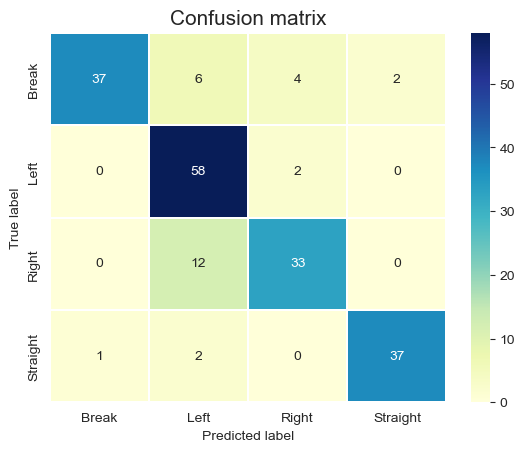

In [19]:
labels = ['Break', 'Left', 'Right', 'Straight']
confusion_Matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_Matrix, xticklabels=labels, yticklabels=labels, annot=True,linewidths = 0.1, fmt="d", cmap = 'YlGnBu')
plt.title("Confusion matrix", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


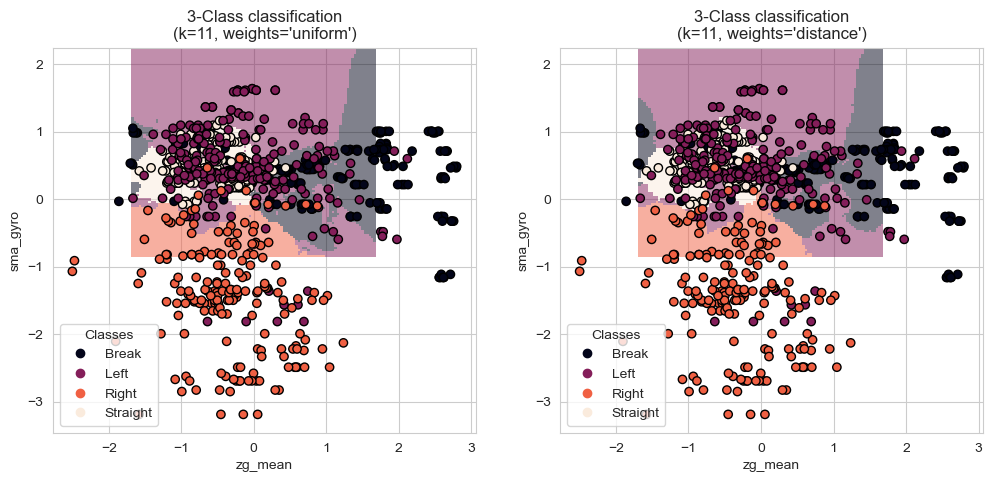

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

colors = ['Break', 'Left', 'Right', 'Straight']
n_classes = ['Break', 'Left', 'Right', 'Straight']
color = []

for i in y_train:
    color.append(colors.index(i))

clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=11))]
)

from sklearn.inspection import DecisionBoundaryDisplay

X = X_train_data_lr[:, [0,23]]


_, axs = plt.subplots(ncols=2, figsize=(12, 5))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test.to_numpy()[:, [5,99]],
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=X_train.columns[5],
        ylabel=X_train.columns[99],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X[:, 0], X[:, 1], c=color, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        colors,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()

In [244]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_data_lr, y_train)

y_pred = rf.predict(X_test_data_lr)

# Evaluate the model
accuracy_before = rf.score(X_test_data_lr, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n -------------Classification Report-------------\n")
print(classification_report(y_test, y_pred))

Accuracy before feature selection: 0.86
Accuracy: 0.8556701030927835

 -------------Classification Report-------------

              precision    recall  f1-score   support

       Break       1.00      0.65      0.79        49
        Left       0.77      0.90      0.83        60
       Right       0.79      0.91      0.85        45
    Straight       0.97      0.97      0.97        40

    accuracy                           0.86       194
   macro avg       0.88      0.86      0.86       194
weighted avg       0.88      0.86      0.85       194



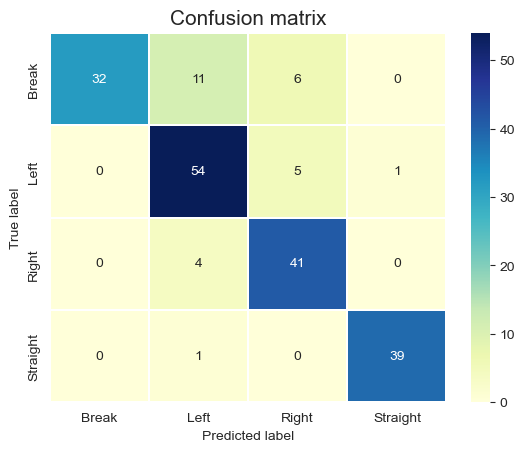

In [245]:
labels = ['Break', 'Left', 'Right', 'Straight']
confusion_Matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_Matrix, xticklabels=labels, yticklabels=labels, annot=True,linewidths = 0.1, fmt="d", cmap = 'YlGnBu')
plt.title("Confusion matrix", fontsize = 15)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [246]:
print(len(labels))
print(X_train.columns)

4
Index(['xa_mean', 'ya_mean', 'za_mean', 'xg_mean', 'yg_mean', 'zg_mean',
       'xa_std', 'ya_std', 'za_std', 'xg_std',
       ...
       'za_argmin', 'xg_argmin', 'yg_argmin', 'zg_argmin', 'xa_arg_diff',
       'ya_arg_diff', 'za_arg_diff', 'xg_arg_diff', 'yg_arg_diff',
       'zg_arg_diff'],
      dtype='object', length=118)


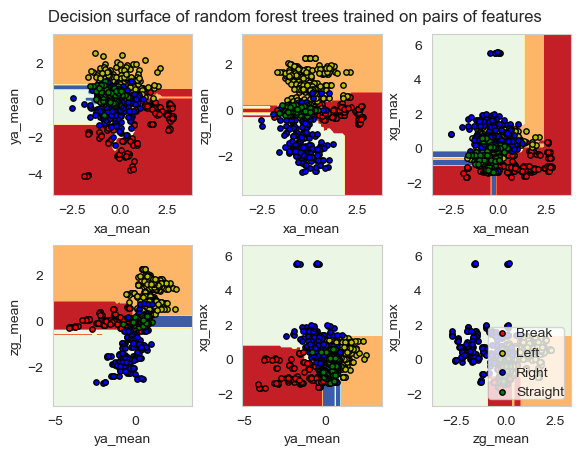

In [247]:
from sklearn.inspection import DecisionBoundaryDisplay

# Parameters
n_classes = ['Break', 'Left', 'Right', 'Straight']
plot_colors = "rybg"
plot_step = 0.02


for pairidx, pair in enumerate([[0, 1], [0, 5], [0, 27], [1, 5], [1, 27], [5, 27]]):
    # We only take the two corresponding features
    X = X_train_data_lr[:, pair]
    y = y_train

    # Train
    clf = RandomForestClassifier(random_state=42, n_estimators=100).fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=X_train.columns[pair[0]],
        ylabel=X_train.columns[pair[1]],
    )

    # Plot the training points
    for i, color in zip(n_classes, plot_colors):
        idx = np.where(y == i)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=i,
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of random forest trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

plt.show()

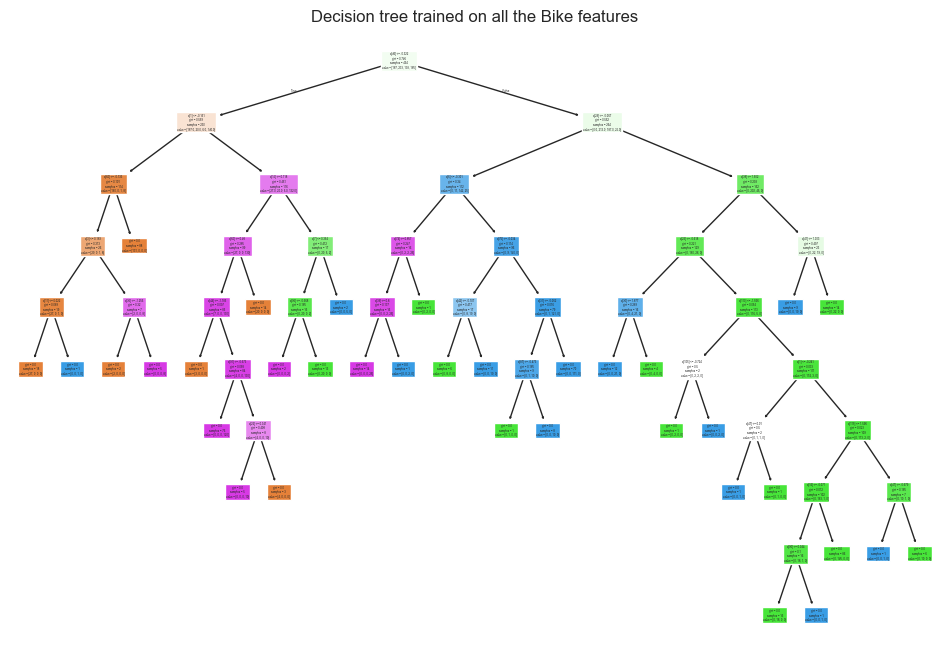

In [248]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(rf.estimators_[0], filled=True)
plt.title("Decision tree trained on all the Bike features")
plt.show()

In [249]:
# Extract feature importances
importances = rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Rank features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print(feature_importance_df[:10])

# Select top N features (example selecting top 10 features)
top_features = feature_importance_df['Feature'][:10].values
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

print(top_features)

            Feature  Importance
5           zg_mean    0.062100
99         sma_gyro    0.048661
23           zg_min    0.042998
41        zg_median    0.041967
1           ya_mean    0.040162
97  avg_result_gyro    0.036371
65     zg_pos_count    0.032084
59     zg_neg_count    0.031820
16           yg_aad    0.031721
50           za_IQR    0.031535
['zg_mean' 'sma_gyro' 'zg_min' 'zg_median' 'ya_mean' 'avg_result_gyro'
 'zg_pos_count' 'zg_neg_count' 'yg_aad' 'za_IQR']


In [250]:
#same as above, but use plotly or plotly express ot allow for an interactive 3d plot
import plotly.express as px

df_plot = pd.DataFrame()

df_plot['x'] = X_train['xg_mean']
df_plot['y'] = X_train['yg_mean']
df_plot['z'] = X_train['zg_mean']
df_plot['label'] = y_train


fig = px.scatter_3d(df_plot, x='x', y='y', z='z',
              color='label',)
fig.update_traces(marker_size = 3)
fig.update_layout(autosize=False, width=800, height=800)
fig.show()

In [251]:
#same as above, but use plotly or plotly express ot allow for an interactive 3d plot
import plotly.express as px

df_plot = pd.DataFrame()

df_plot['x'] = X_train['xa_mean']
df_plot['y'] = X_train['ya_mean']
df_plot['z'] = X_train['za_mean']
df_plot['label'] = y_train


fig = px.scatter_3d(df_plot, x='x', y='y', z='z',
              color='label',)
fig.update_traces(marker_size = 3)
fig.update_layout(autosize=False, width=800, height=800)
fig.show()


In [252]:
#same as above, but use plotly or plotly express ot allow for an interactive 3d plot
import plotly.express as px

df_plot = pd.DataFrame()

df_plot['x'] = X_train['xg_max']
df_plot['y'] = X_train['yg_max']
df_plot['z'] = X_train['zg_max']
df_plot['label'] = y_train


fig = px.scatter_3d(df_plot, x='x', y='y', z='z',
              color='label',)
fig.update_traces(marker_size = 3)
fig.update_layout(autosize=False, width=800, height=800)
fig.show()



In [253]:
#same as above, but use plotly or plotly express ot allow for an interactive 3d plot
import plotly.express as px

df_plot = pd.DataFrame()

df_plot['x'] = X_train['xg_arg_diff']
df_plot['y'] = X_train['yg_arg_diff']
df_plot['z'] = X_train['zg_arg_diff']
df_plot['label'] = y_train


fig = px.scatter_3d(df_plot, x='x', y='y', z='z',
              color='label',)
fig.update_traces(marker_size = 3)
fig.update_layout(autosize=False, width=800, height=800)
fig.show()


In [254]:
df_plot

,x,y,z,label
0,1,8,25,Break
1,94,6,91,Break
2,11,46,38,Break
3,66,17,13,Break
4,28,17,13,Break
...,...,...,...,...
773,10,1,76,Right
774,41,1,69,Right
775,57,42,84,Right
776,8,42,9,Right


In [255]:
X_train = X_train[['sma_gyro', 'zg_mean', 'ya_mean', 'xa_mean', 'xg_max', 'za_IQR']]
X_test = X_test[['sma_gyro', 'zg_mean', 'ya_mean', 'xa_mean', 'xg_max', 'za_IQR']]